<a href="https://colab.research.google.com/github/Bunkhuoch-Ann/Side_Quests_simple/blob/main/Unit_normalization_for_3_body_sim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],   # main text font
    "mathtext.fontset": "stix",      # math font (for $...$)
    "font.size": 20,
    "axes.linewidth": 2.3,        # thick frame
    "xtick.direction": "in",      # ticks inward
    "ytick.direction": "in",
    "xtick.top": True,            # ticks on all sides
    "ytick.right": True,
    "xtick.major.size": 10,
    "xtick.labelsize": 20,
    "ytick.major.size": 10,
    "ytick.labelsize": 20,
    "xtick.minor.size": 7,
    "ytick.minor.size": 7
})

In [38]:
import scipy.constants as const

G = const.G
#distance from earth to the sun in m
dist = 150*1e9
solmass = 2*1e30

print(f"The Newton constant (G) is: {G} m^3 kg^-1 s^-2")
l = np.arange(10,1000, 10) #in AU
m = np.arange(1, 100) #in solar mass

Tsec = np.sqrt((l*dist)**3/(G*m*solmass))
Tday = Tsec/(24*60*60)
Tyear = Tsec/(24*60*60*365)

vel1 = np.sqrt(G*m*solmass/(l*dist))/1e3
vel2 = (l*dist/Tsec)/1e3

diffv = vel1 - vel2
np.mean(diffv)

The Newton constant (G) is: 6.6743e-11 m^3 kg^-1 s^-2


np.float64(-7.177199351112124e-17)

The time period at M=5 Solar Masses and L=100 AU is: 71.31 years


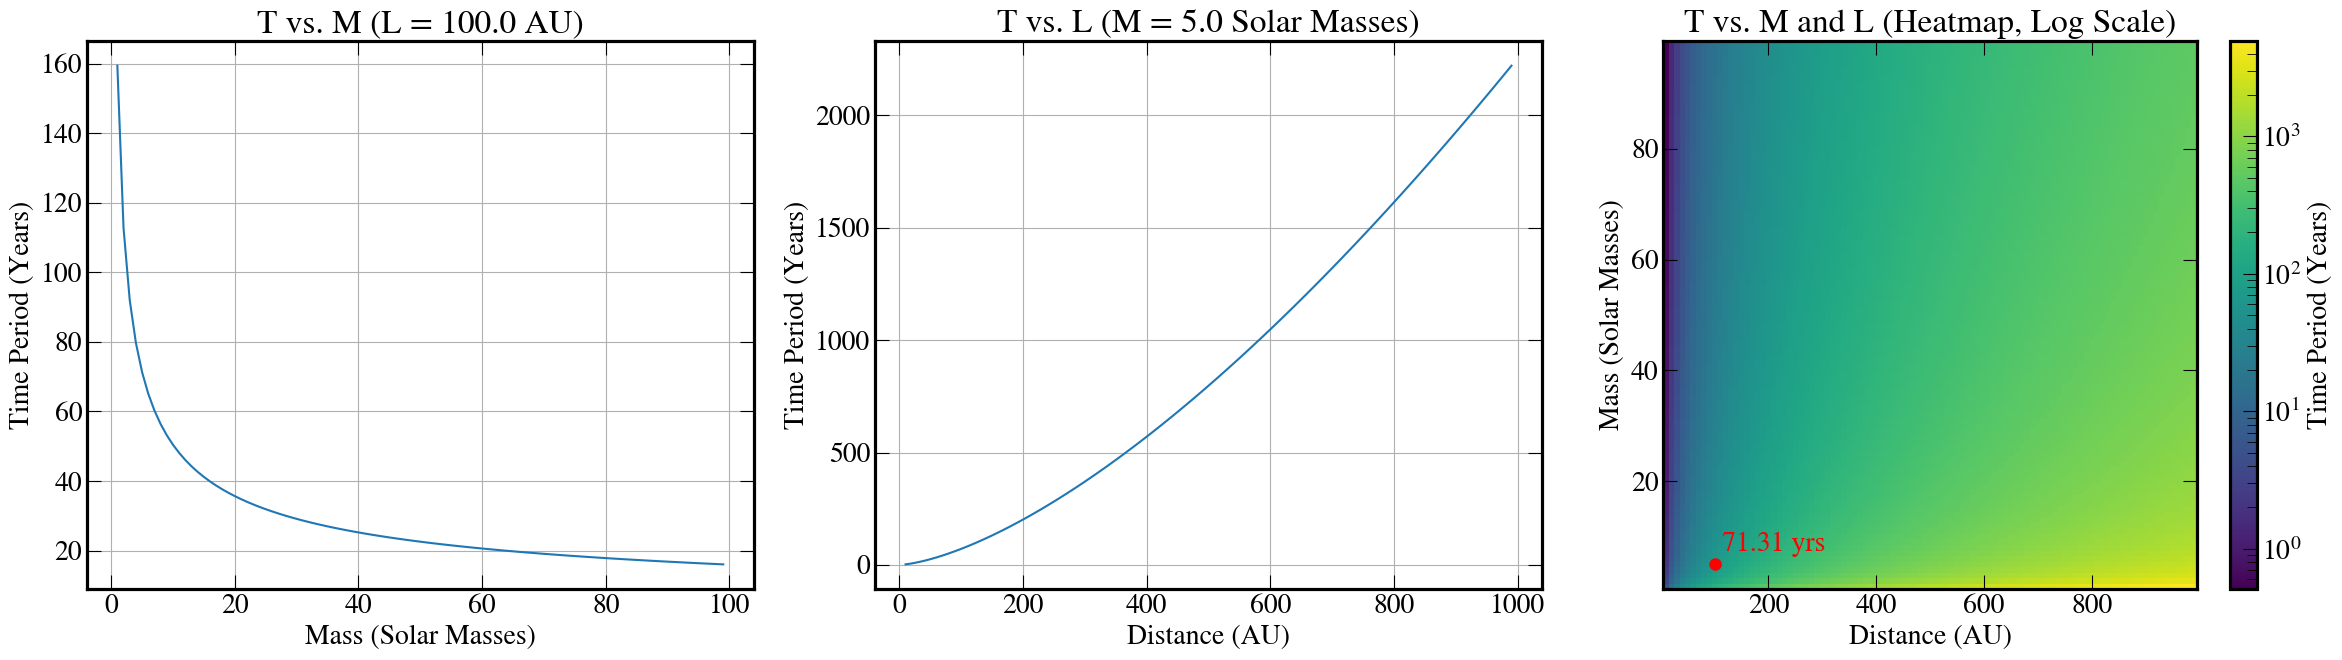

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as colors # Import for logarithmic scale

# Assuming G, dist, solmass are available from previous cells.
# Recalculate l and m as grids to compute T for all combinations
l_au = np.arange(10, 1000, 10) # in AU, represents L
m_solmass = np.arange(1, 100) # in solar mass, represents M

# Create 2D grids for L and M
L_grid, M_grid = np.meshgrid(l_au, m_solmass)

# Calculate Tsec for the grid (using G, dist, solmass from previous cell)
# `dist` converts AU to meters, `solmass` converts solar mass to kg
Tsec_grid = np.sqrt((L_grid * dist)**3 / (G * M_grid * solmass))
Tyear_grid = Tsec_grid / (24 * 60 * 60 * 365) # Convert to years

# Choose fixed values for 2D plots
#fixed_l_val = np.median(l_au)
fixed_l_val = 100
fixed_l_idx = np.argmin(np.abs(l_au - fixed_l_val))

#fixed_m_val = np.median(m_solmass)
fixed_m_val = 5
fixed_m_idx = np.argmin(np.abs(m_solmass - fixed_m_val))

# Create a figure with 1 row and 3 columns for side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# --- Plot 1: T as a function of M (for a fixed L) ---
axes[0].plot(m_solmass, Tyear_grid[:, fixed_l_idx])
axes[0].set_xlabel("Mass (Solar Masses)")
axes[0].set_ylabel("Time Period (Years)")
axes[0].set_title(f"T vs. M (L = {fixed_l_val:.1f} AU)")
axes[0].grid(True)

# --- Plot 2: T as a function of L (for a fixed M) ---
axes[1].plot(l_au, Tyear_grid[fixed_m_idx, :])
axes[1].set_xlabel("Distance (AU)")
axes[1].set_ylabel("Time Period (Years)")
axes[1].set_title(f"T vs. L (M = {fixed_m_val:.1f} Solar Masses)")
axes[1].grid(True)

# --- Plot 3: Heatmap of T as a function of M and L ---
# Use pcolormesh on the third subplot with a logarithmic color scale
mesh = axes[2].pcolormesh(L_grid,
                           M_grid,
                           Tyear_grid,
                           norm=colors.LogNorm(vmin=Tyear_grid.min(), vmax=Tyear_grid.max()),
                           shading='auto',
                           cmap='viridis')
fig.colorbar(mesh, ax=axes[2], label="Time Period (Years)")
axes[2].set_xlabel("Distance (AU)")
axes[2].set_ylabel("Mass (Solar Masses)")
axes[2].set_title("T vs. M and L (Heatmap, Log Scale)")

# --- Mark and annotate a specific point on the heatmap (third panel) ---
# Target M=2 (Solar Masses) and L=100 (AU)

target_L = 100 # AU
target_M = 5 # Solar Masses

# Find the index for target_L and target_M in the original l_au and m_solmass arrays
l_idx = np.where(l_au == target_L)[0]
m_idx = np.where(m_solmass == target_M)[0]

if l_idx.size > 0 and m_idx.size > 0:
    # Get the orbital period at the target point
    orbital_period_at_point = Tyear_grid[m_idx[0], l_idx[0]]

    # Plot a red marker at the specified (L, M) coordinates
    axes[2].plot(target_L, target_M, 'o', color='red', markersize=8, label=f'M={target_M}, L={target_L}')

    # Annotate the marker with its value
    axes[2].annotate(f'{orbital_period_at_point:.2f} yrs',
                     (target_L, target_M),
                     textcoords="offset points",
                     xytext=(5,5),
                     ha='left', va='bottom', color='red')
    print(f"The time period at M={target_M} Solar Masses and L={target_L} AU is: {orbital_period_at_point:.2f} years")

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

The orbital velocity at M=5 Solar Masses and L=100 AU is: 6.67 km/s


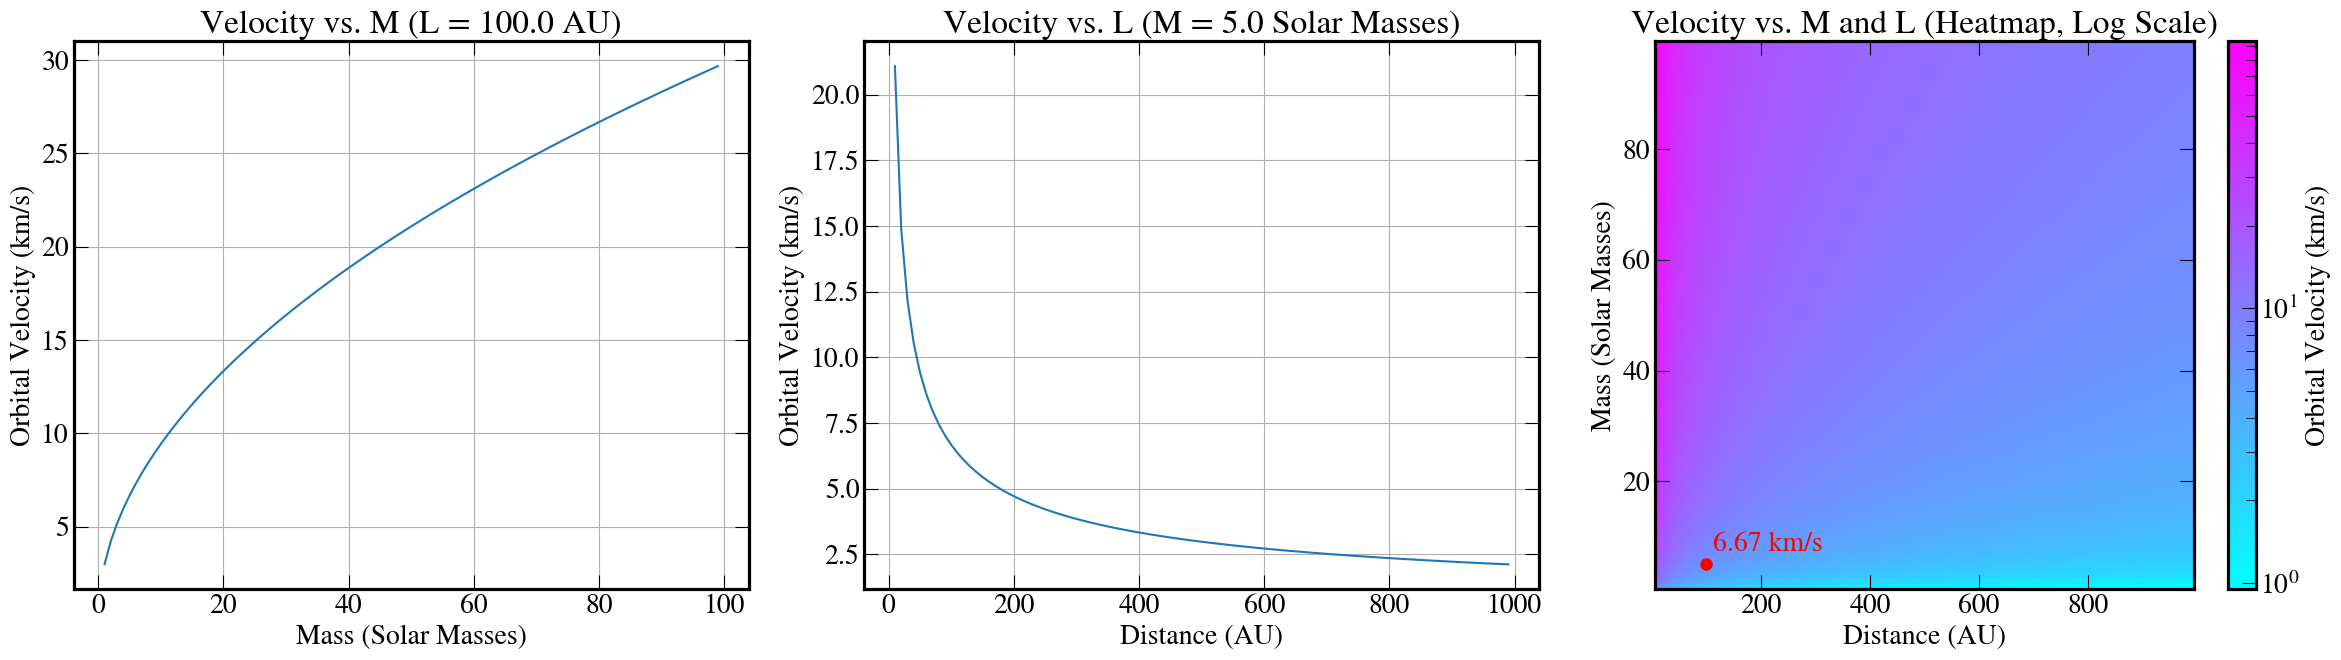

In [50]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as colors # Import for logarithmic scale

# Grids for L and M are already defined in previous cells as L_grid and M_grid
# G, dist, solmass are also available from previous cells.

# Calculate velocity (in km/s) for the grid
# Using the formula vel = sqrt(G * M * solmass / (L * dist))
# Divide by 1e3 to convert m/s to km/s
vel_grid = np.sqrt(G * M_grid * solmass / (L_grid * dist)) / 1e3

# Fixed values for 2D plots (using the same logic as the previous cell)
#fixed_l_val = np.median(l_au)
fixed_l_idx = np.argmin(np.abs(l_au - fixed_l_val))

#fixed_m_val = np.median(m_solmass)
fixed_m_idx = np.argmin(np.abs(m_solmass - fixed_m_val))

# Create a figure with 1 row and 3 columns for side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# --- Plot 1: Velocity as a function of M (for a fixed L) ---
axes[0].plot(m_solmass, vel_grid[:, fixed_l_idx])
axes[0].set_xlabel("Mass (Solar Masses)")
axes[0].set_ylabel("Orbital Velocity (km/s)")
axes[0].set_title(f"Velocity vs. M (L = {fixed_l_val:.1f} AU)")
axes[0].grid(True)

# --- Plot 2: Velocity as a function of L (for a fixed M) ---
axes[1].plot(l_au, vel_grid[fixed_m_idx, :])
axes[1].set_xlabel("Distance (AU)")
axes[1].set_ylabel("Orbital Velocity (km/s)")
axes[1].set_title(f"Velocity vs. L (M = {fixed_m_val:.1f} Solar Masses)")
axes[1].grid(True)

# --- Plot 3: Heatmap of Velocity as a function of M and L ---
# Use pcolormesh on the third subplot with a logarithmic color scale
mesh = axes[2].pcolormesh(L_grid,
                           M_grid,
                           vel_grid,
                           norm=colors.LogNorm(vmin=vel_grid.min(), vmax=vel_grid.max()),
                           shading='auto',
                           cmap='cool') # Changed cmap for differentiation from T
fig.colorbar(mesh, ax=axes[2], label="Orbital Velocity (km/s)")
axes[2].set_xlabel("Distance (AU)")
axes[2].set_ylabel("Mass (Solar Masses)")
axes[2].set_title("Velocity vs. M and L (Heatmap, Log Scale)")

# --- Mark and annotate a specific point on the heatmap (third panel) ---
# Target M=2 (Solar Masses) and L=100 (AU) as per initial user request
target_L = 100 # AU
target_M = 5 # Solar Masses

# Find the index for target_L and target_M in the original l_au and m_solmass arrays
l_idx = np.where(l_au == target_L)[0]
m_idx = np.where(m_solmass == target_M)[0]

if l_idx.size > 0 and m_idx.size > 0:
    # Get the orbital velocity at the target point
    orbital_velocity_at_point = vel_grid[m_idx[0], l_idx[0]]

    # Plot a red marker at the specified (L, M) coordinates
    axes[2].plot(target_L, target_M, 'o', color='red', markersize=8, label=f'M={target_M}, L={target_L}')

    # Annotate the marker with its value
    axes[2].annotate(f'{orbital_velocity_at_point:.2f} km/s',
                     (target_L, target_M),
                     textcoords="offset points",
                     xytext=(5,5),
                     ha='left', va='bottom', color='red')
    print(f"The orbital velocity at M={target_M} Solar Masses and L={target_L} AU is: {orbital_velocity_at_point:.2f} km/s")

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()